 $\textbf{This notebook is dedicated for studying Neural Networks. It contains detailed study of its hyper-parameters, and remarks about how they affect performance and optimization.}$
 
 $\textbf{The neural network implementation used here is the MLP (Multi-Layer Perceptron) classifier from sklearn.}$

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

sys.path.append(os.path.abspath('../src'))
from DataLoader import DataLoader
from DataSplitter import DataSplitter
from Transformer import Transformer
from PreProcessorSimple import PreProcessorSimple
from PreProcessorNN import PreProcessorNN
from PipelineBuilder import PipelineBuilder
from CrossValidation import CrossValidation

### Dataset

In [2]:
data_loader = DataLoader("../data/train.csv", "../data/test.csv")
train, test = data_loader.load()

In [3]:
data_splitter = DataSplitter(target_column="label")
X_train, X_test, y_train, y_test = data_splitter.split(train)
X, y = train.drop(columns=['label']), train['label']
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_train.shape[0]/(X_train.shape[0] + X_test.shape[0])

((33600, 784), (8400, 784), (33600,), (8400,), 0.8)

### ML Pipeline

In [4]:
## ML pipeline builder
pipeline_builder = PipelineBuilder(train)

### MLP Classifier (Neural Network)

In [5]:
pipeline = pipeline_builder.build(model_name="MLP")
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

#### Hyper-parameters Study:

In [6]:
# Tu run Holdout Validation on a reduced size train dataset, activate this flag: 
# If this isn't activated, the validations will use the entire train dataset and will ignore the train_size flags bellow
reduced = False

# For very fast training, but poor interpretability, use the following flag:
fast_train_size = 1000
# for fast training and good interpretability, use the following flag instead:
reduced_train_size = 20000

# Choose which flag you will use
train_size = fast_train_size

In [7]:
## Plot Loss curves and validation score curves
def plot_loss_validation_curves(loss_curves, validation_score_curves, ncols, param_name, grid_key):
    nrows = 2*len(loss_curves)//ncols
    fig, ax = plt.subplots(figsize=(12,4*nrows), nrows=nrows, ncols=ncols)
    fig.subplots_adjust(hspace=0.5)
    
    for i in range(len(loss_curves)):
        k, v = list(loss_curves.keys())[i], list(loss_curves.values())[i]
        epochs = [epoch for epoch in range(1, len(v)+1)]
        row, col = (2*i)//ncols, (2*i)%ncols
        title = param_name + " = " + str(ast.literal_eval(k)[grid_key])
        
        ax[row,col].plot(epochs, loss_curves[k], color='blue')
        ax[row,col].set_title(title)
        ax[row,col].set_xlabel("Epochs")
        ax[row,col].set_ylabel("Loss in Training")
        ax[row,col].grid(True)

        validation_curve = validation_score_curves[k]
        if np.isscalar(validation_curve) and np.isnan(validation_curve):
            validation_curve = np.full(len(epochs), np.nan)
        ax[row,col+1].plot(epochs, validation_curve, color='blue')
        ax[row,col+1].set_title(title)
        ax[row,col+1].set_xlabel("Epochs")
        ax[row,col+1].set_ylabel("Validation Score")
        ax[row,col+1].grid(True)
    plt.show()

$\textbf{Studying Epochs:}$

In [8]:
## Hyper-parameter tunning
cv = CrossValidation(pipeline=clone(pipeline))
param_grid = {
    "model__max_iter": [3, 6, 8, 10, 20, 40, 60, 80, 100, 150],
    "model__early_stopping": [False],
    "model__tol": [1e-12],
    "model__n_iter_no_change": [300],
}
cv_mlp_results, loss_curves, validation_score_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
                                                                                    reduced=reduced, train_size=train_size, 
                                                                                    return_loss_curves=True)
cv_mlp_results

C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 3, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 9.332064867019653
Prediction time: 0.21848416328430176



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (6) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 6, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 17.07002091407776
Prediction time: 0.22690153121948242



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (8) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 8, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 24.597972631454468
Prediction time: 0.17970705032348633



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 10, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 30.062231063842773
Prediction time: 0.233109712600708



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 20, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 51.475152254104614
Prediction time: 0.2602519989013672



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 40, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 86.96983289718628
Prediction time: 0.32563233375549316



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 60, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 134.19358229637146
Prediction time: 0.3241689205169678



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 80, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 181.35003399848938
Prediction time: 0.3354074954986572



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 100, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 246.4104585647583
Prediction time: 0.3681516647338867



C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


Params:  {'model__early_stopping': False, 'model__max_iter': 150, 'model__n_iter_no_change': 300, 'model__tol': 1e-12}
Fit time: 465.3292455673218
Prediction time: 0.5982208251953125

Total CV time: 1249.9511587619781



,model__early_stopping,model__max_iter,model__n_iter_no_change,model__tol,fit_time,pred_time,epochs,final_loss,final_validation_score,score
5,False,40,300,1.000000e-12,86.969833,0.325632,40,0.000452,NaN,0.971905
7,False,80,300,1.000000e-12,181.350034,0.335407,80,0.000445,NaN,0.971310
9,False,150,300,1.000000e-12,465.329246,0.598221,150,0.000534,NaN,0.970833
4,False,20,300,1.000000e-12,51.475152,0.260252,20,0.001713,NaN,0.968810
8,False,100,300,1.000000e-12,246.410459,0.368152,100,0.000569,NaN,0.968810
3,False,10,300,1.000000e-12,30.062231,0.233110,10,0.010349,NaN,0.968810
6,False,60,300,1.000000e-12,134.193582,0.324169,60,0.002968,NaN,0.968690
2,False,8,300,1.000000e-12,24.597973,0.179707,8,0.019130,NaN,0.966905
1,False,6,300,1.000000e-12,17.070021,0.226902,6,0.036584,NaN,0.965000
0,False,3,300,1.000000e-12,9.332065,0.218484,3,0.094383,NaN,0.958452


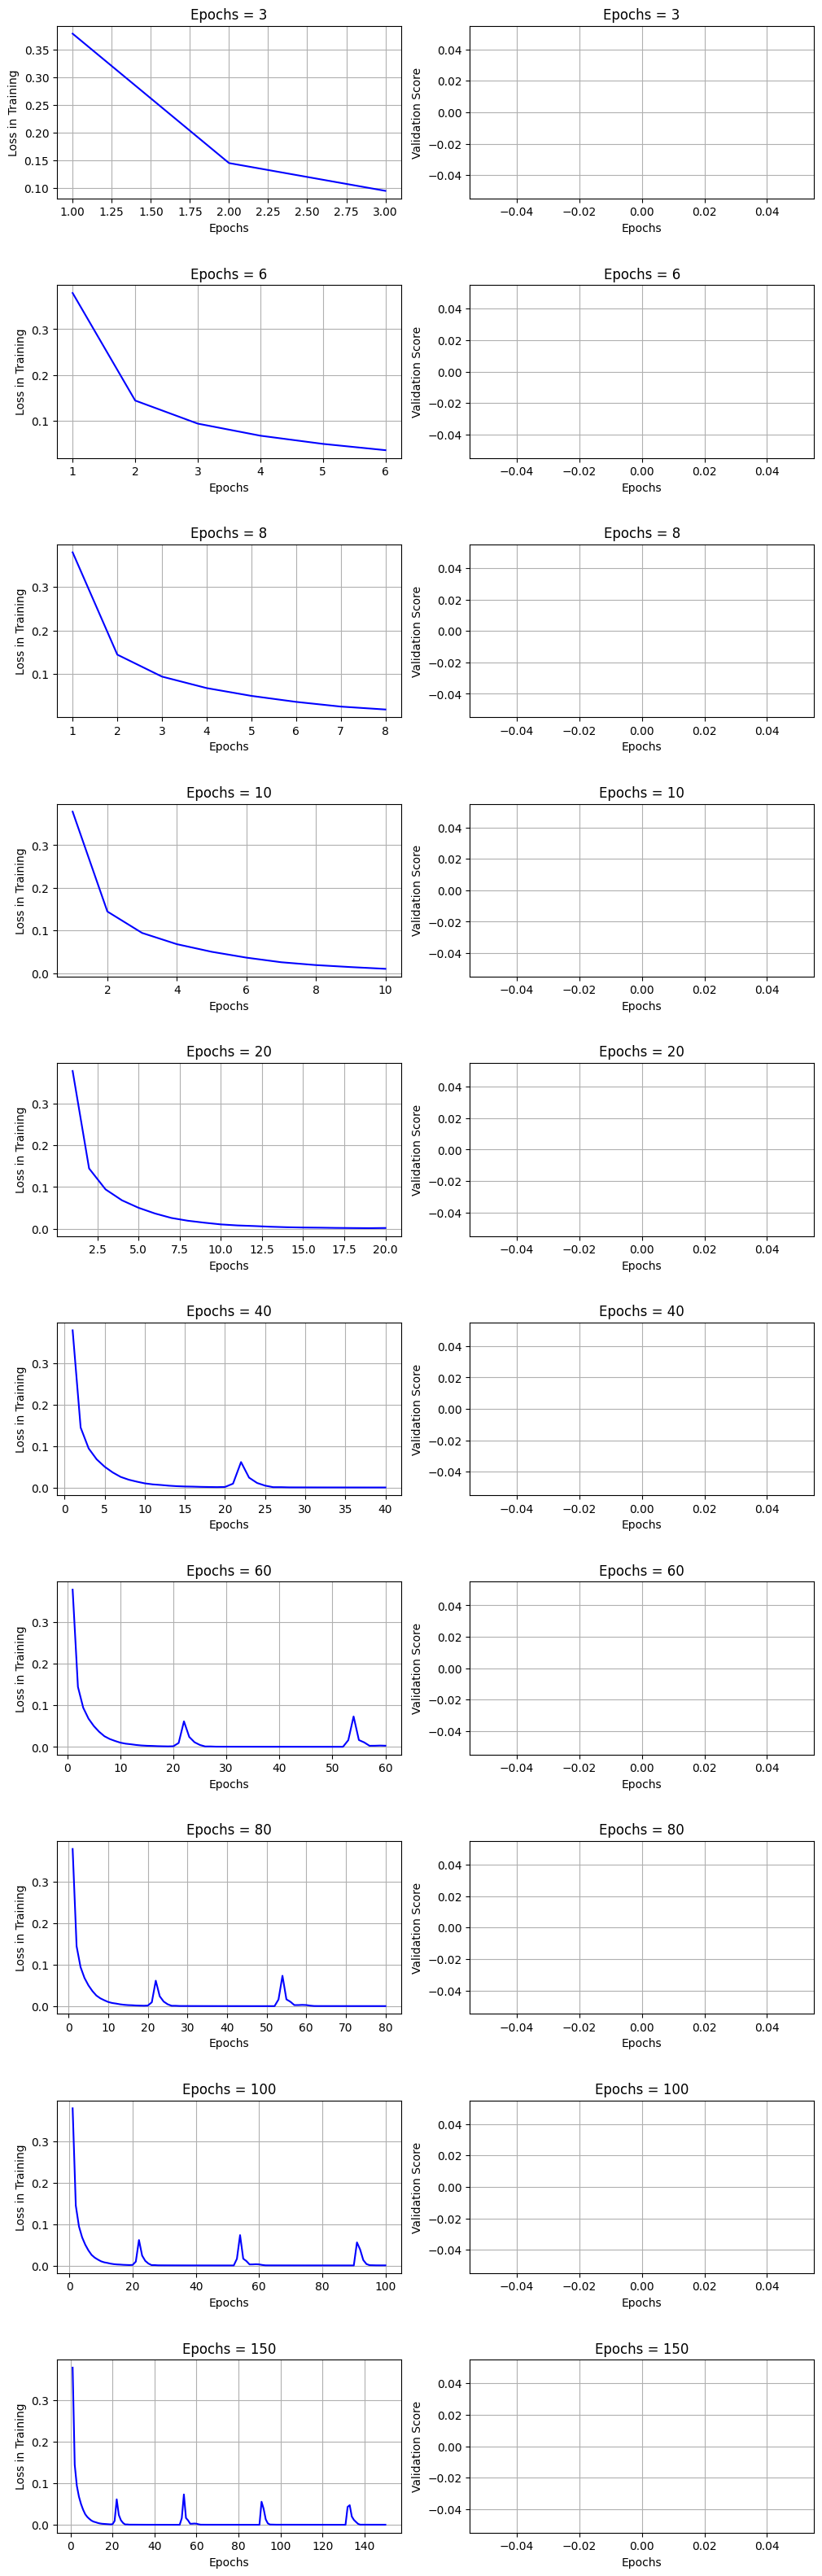

In [9]:
plot_loss_validation_curves(loss_curves, validation_score_curves, 2, "Epochs", "model__max_iter")

$\textbf{Remarks about Epoch:}$
- Fitting time increases linearly with number of epochs.
- The more epochs we have, the smaller the loss function becomes (and the better the CV score becomes), until approximately 40 epochs, where it seems to converge. 

$\textbf{Studying Learning Rate:}$

In [10]:
## Hyper-parameter tunning
cv = CrossValidation(pipeline=clone(pipeline))
param_grid = {
    "model__learning_rate_init": [1e-5, 1e-4, 1e-3, 5e-3, 1e-2, 1e-1, 2e-1, 5e-1],
}
cv_mlp_results, loss_curves, validation_score_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
                                                                                    reduced=reduced, train_size=train_size, 
                                                                                    return_loss_curves=True)
cv_mlp_results

Params:  {'model__learning_rate_init': 1e-05}
Fit time: 651.5651850700378
Prediction time: 3.1354029178619385

Params:  {'model__learning_rate_init': 0.0001}
Fit time: 183.18552780151367
Prediction time: 0.6253848075866699

Params:  {'model__learning_rate_init': 0.001}
Fit time: 83.69461131095886
Prediction time: 0.6502976417541504

Params:  {'model__learning_rate_init': 0.005}
Fit time: 121.24106669425964
Prediction time: 0.4295036792755127

Params:  {'model__learning_rate_init': 0.01}
Fit time: 86.80838513374329
Prediction time: 0.49685168266296387

Params:  {'model__learning_rate_init': 0.1}
Fit time: 83.52164793014526
Prediction time: 0.3471353054046631

Params:  {'model__learning_rate_init': 0.2}
Fit time: 101.88942551612854
Prediction time: 0.44071030616760254

Params:  {'model__learning_rate_init': 0.5}
Fit time: 86.10297083854675
Prediction time: 0.4607722759246826

Total CV time: 1404.8094058036804



,model__learning_rate_init,fit_time,pred_time,epochs,final_loss,final_validation_score,score
2,0.00100,83.694611,0.650298,31,0.000711,0.966369,0.968690
3,0.00500,121.241067,0.429504,64,0.036143,0.958036,0.965119
6,0.20000,101.889426,0.440710,53,10.174987,0.962798,0.963929
7,0.50000,86.102971,0.460772,54,63.593943,0.957440,0.963690
5,0.10000,83.521648,0.347135,39,2.045884,0.956250,0.962738
1,0.00010,183.185528,0.625385,50,0.013998,0.957440,0.962619
4,0.01000,86.808385,0.496852,41,0.087798,0.963095,0.960833
0,0.00001,651.565185,3.135403,176,0.063605,0.949702,0.956190


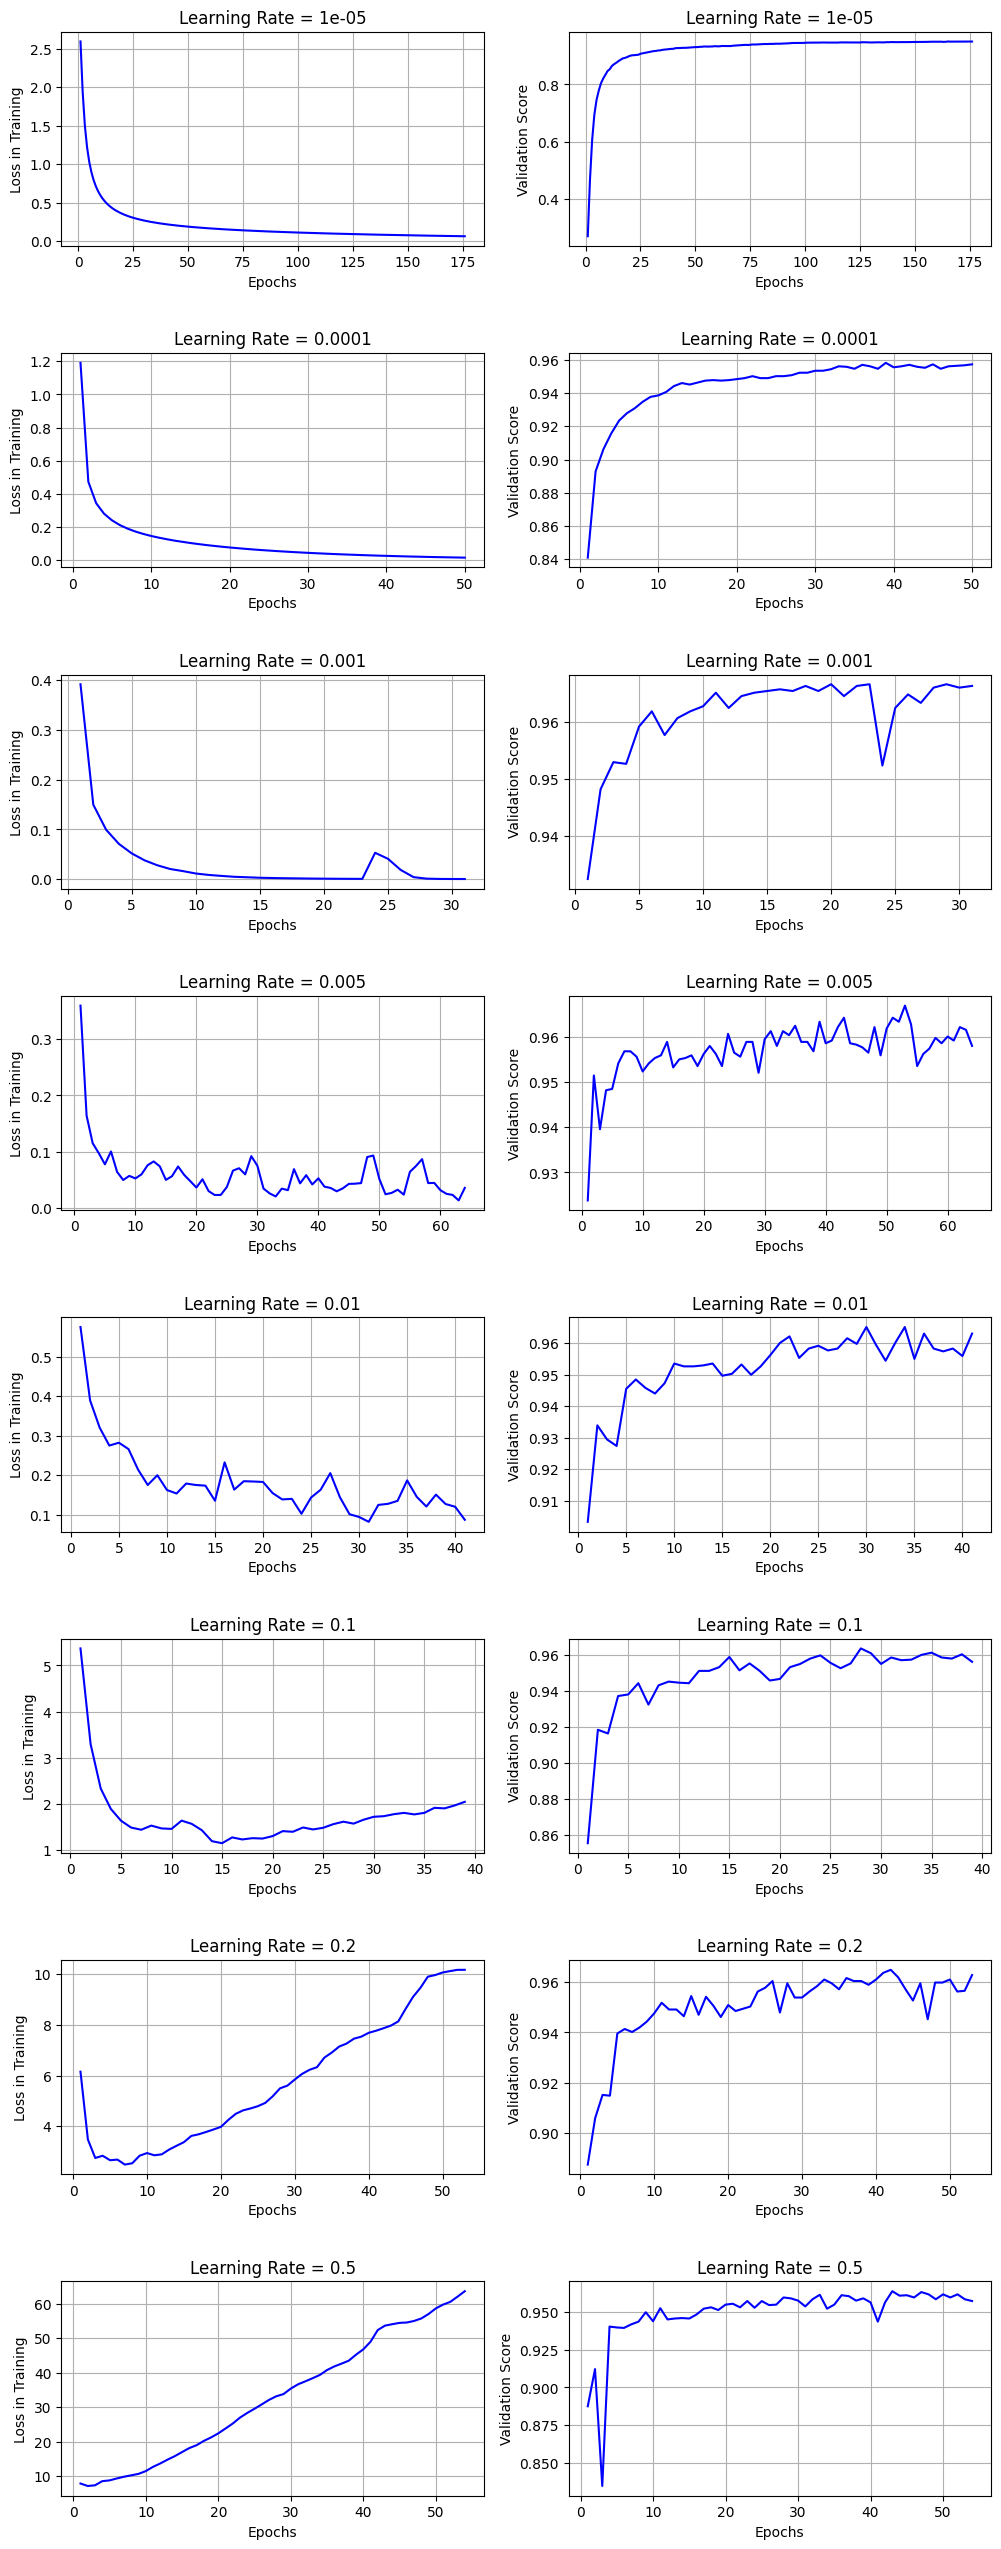

In [11]:
plot_loss_validation_curves(loss_curves, validation_score_curves, 2, "Learning Rate", "model__learning_rate_init")

$\textbf{Remarks about Learning Rate}:$
- Very low values result in slow convergence (more epochs).
- Lower values give smoother convergence. From 0.005 we observe that the loss curve becomes noisier.
- Bigger values mean big steps in gradient descent, which can struggle to find the local minimias cause of constant overshooting. We observe this effect for learning rate=0.2. Since the step is too big, the loss function overshoots around the minima and constantly finds itself in worse values.
- Values that are too low, even though they have more conservative steps and may find minimas easily, may still not be better than slightly bigger steps. This happens because very low values find sharp minimas easily, which may not generalize well. Slightly bigger steps, on the other hand, may not find these very sharp minimas, but will easily find flat minimas. Flat minimas generalzie well since perturbations in the parameter grid don't change too much the loss function value. This effect is observed when we look at the CV scores of 1e-5, 1e-4 and 1e-3, and conclude that 1e-3 has a better score.
- Terrible loss curves can unintuitively have great CV scores. This happens because CV score sees accuracy (right or wrong), while loss function sees the distance in probability space between prediction and true value. If the estimator classifies an observation with probability 0.51, CV sees that it is correct, but loss sees that the probability is far from ideal. If the model makes very few mistakes very confidently, it can still be very accurate with a terrible loss value. This can be a problem, but it also may not be a problem, depending on if the test set will have observations similar to those in which it is very confidently making mistakes.

$\textbf{Studying Hidden Layer Sizes:}$

In [12]:
## Hyper-parameter tunning
cv = CrossValidation(pipeline=clone(pipeline))
param_grid = {
    "model__hidden_layer_sizes": [(16,), (32,), (64,), (128,), (256,), (512,), (2048,)],    # Width study
    #"model__hidden_layer_sizes": [(128,), (128,64), (128,64,32), (128,64,32,16)],          # Depth study
}
cv_mlp_results, loss_curves, validation_score_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
                                                                                    reduced=reduced, train_size=train_size, 
                                                                                    return_loss_curves=True)
cv_mlp_results

Params:  {'model__hidden_layer_sizes': (16,)}
Fit time: 17.046992778778076
Prediction time: 0.38728904724121094

Params:  {'model__hidden_layer_sizes': (32,)}
Fit time: 27.95079731941223
Prediction time: 0.32155537605285645

Params:  {'model__hidden_layer_sizes': (64,)}
Fit time: 31.358752250671387
Prediction time: 0.3322443962097168

Params:  {'model__hidden_layer_sizes': (128,)}
Fit time: 53.74358773231506
Prediction time: 0.36484265327453613

Params:  {'model__hidden_layer_sizes': (256,)}
Fit time: 140.51426696777344
Prediction time: 0.7024867534637451

Params:  {'model__hidden_layer_sizes': (512,)}
Fit time: 181.01030468940735
Prediction time: 0.42687392234802246

Params:  {'model__hidden_layer_sizes': (2048,)}
Fit time: 685.5646848678589
Prediction time: 1.2207317352294922

Total CV time: 1141.0150182247162



,model__hidden_layer_sizes,fit_time,pred_time,epochs,final_loss,final_validation_score,score
4,"(256,)",140.514267,0.702487,28,0.000462,0.970536,0.972381
5,"(512,)",181.010305,0.426874,20,0.002807,0.972321,0.970476
3,"(128,)",53.743588,0.364843,31,0.000711,0.966369,0.968690
6,"(2048,)",685.564685,1.220732,18,0.010442,0.962798,0.966310
2,"(64,)",31.358752,0.332244,27,0.016721,0.961905,0.965119
1,"(32,)",27.950797,0.321555,28,0.010957,0.955357,0.955952
0,"(16,)",17.046993,0.387289,22,0.077397,0.934524,0.940833


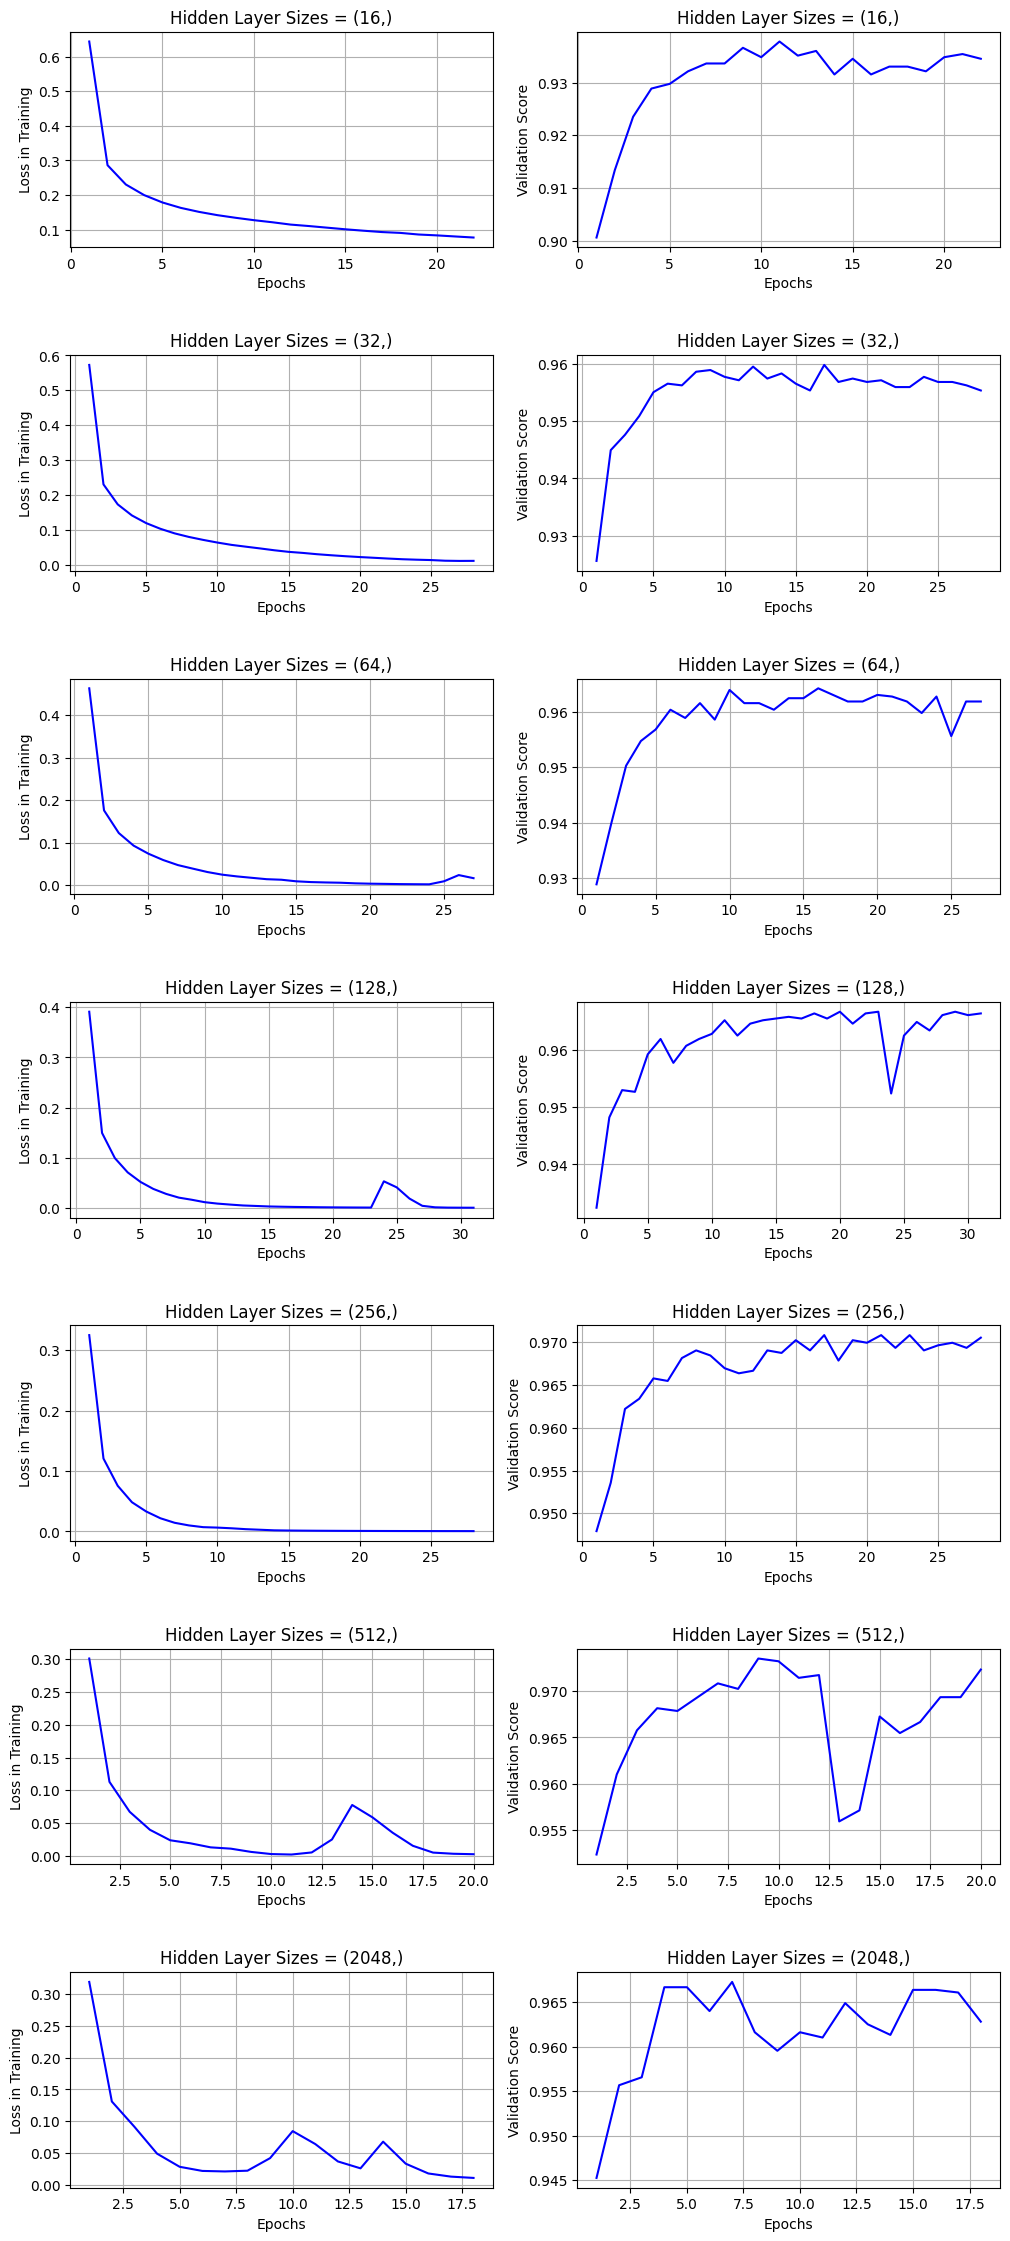

In [13]:
plot_loss_validation_curves(loss_curves, validation_score_curves, 2, "Hidden Layer Sizes", "model__hidden_layer_sizes")

$\textbf{Remarks about Hidden Layer Sizes}:$

$\textbf{Width Study}:$
- The more neurons, the longer the fitting time (almost linear).
- The more neurons, the smaller the loss curve value, and the better the CV score. Until 256 neurons, the added capacity gives good marginal gains. After that, the capacity seems to saturate and the gains are two small to be worth the computational cost (and optimization unstability).
- Larger models are more prone to optimization instability since they have more directions in gradient descent, and mini-batch noise may make the gradient descent trajectory less smooth (less constrained) -> we see more spikes in the loss curves of larger models. Optimization instability doesn't mean the model is bad. It may still get to a good solution, but the path to this solution will be harder. Larger models are also more prone to overfitting obviously (2048 neurones results in a bad CV score).

$\textbf{Depth Study}:$
- We do not clearly see the advantage of using deeper NNs in this dataset. Sklearn is not optimized to optimization stability of deep NNs, so we don't really benefit from going deep cause we're hurt by unstability (loss curve is a little bit unstable for more than 2 layers).
- 2 layers slightly improve the CV score, although it could be only noise since we're only doing a one-fold holdout validation.

$\textbf{Studying Activation Function:}$

In [14]:
## Hyper-parameter tunning
cv = CrossValidation(pipeline=clone(pipeline))
param_grid = {
    "model__activation": ["relu", "tanh", "logistic", "identity"],
}
cv_mlp_results, loss_curves, validation_score_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
                                                                                    reduced=reduced, train_size=train_size, 
                                                                                    return_loss_curves=True)
cv_mlp_results

Params:  {'model__activation': 'relu'}
Fit time: 84.9693968296051
Prediction time: 0.5842933654785156

Params:  {'model__activation': 'tanh'}
Fit time: 97.16578531265259
Prediction time: 0.7572059631347656

Params:  {'model__activation': 'logistic'}
Fit time: 83.95997190475464
Prediction time: 0.41577720642089844

Params:  {'model__activation': 'identity'}
Fit time: 55.291048765182495
Prediction time: 0.3773982524871826

Total CV time: 323.5537872314453



,model__activation,fit_time,pred_time,epochs,final_loss,final_validation_score,score
0,relu,84.969397,0.584293,31,0.000711,0.966369,0.968690
2,logistic,83.959972,0.415777,33,0.004854,0.956548,0.959048
1,tanh,97.165785,0.757206,33,0.000751,0.953274,0.958571
3,identity,55.291049,0.377398,23,0.217046,0.908036,0.914167


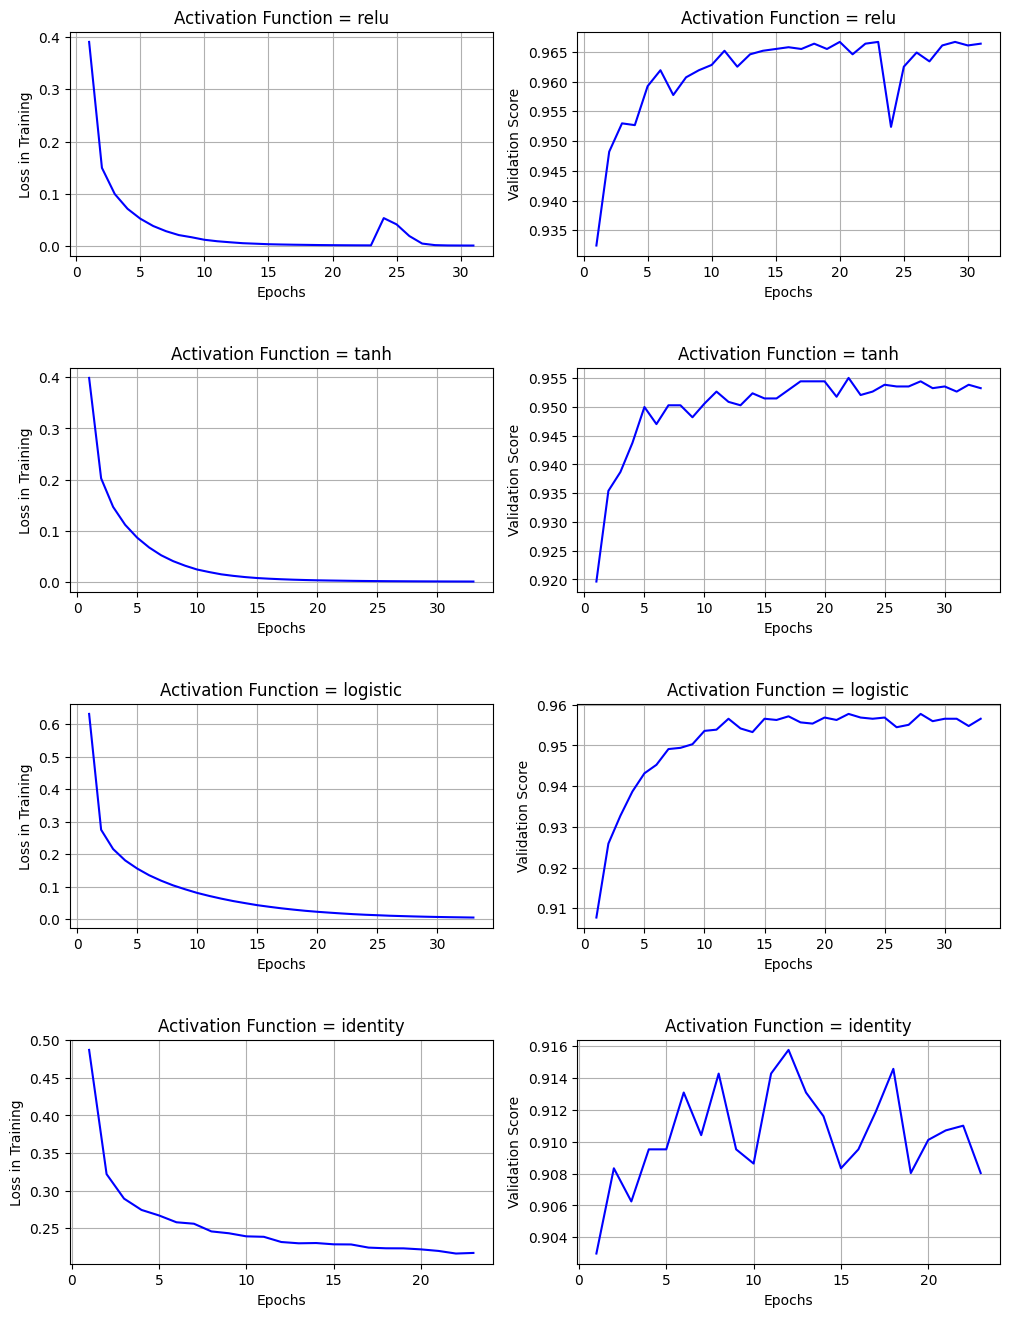

In [15]:
plot_loss_validation_curves(loss_curves, validation_score_curves, 2, "Activation Function", "model__activation")

$\textbf{Remarks about Activation Function}:$
- Relu performs better than the other activation functions.

$\textbf{Studying Alpha (L2 Regularization)}$

In [16]:
## Hyper-parameter tunning
cv = CrossValidation(pipeline=clone(pipeline))
param_grid = {
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
}
cv_mlp_results, loss_curves, validation_score_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
                                                                                    reduced=reduced, train_size=train_size, 
                                                                                    return_loss_curves=True)
cv_mlp_results

Params:  {'model__alpha': 1e-06}
Fit time: 100.24411153793335
Prediction time: 0.5668911933898926

Params:  {'model__alpha': 1e-05}
Fit time: 143.3715295791626
Prediction time: 0.5447161197662354

Params:  {'model__alpha': 0.0001}
Fit time: 84.35267496109009
Prediction time: 0.40926599502563477

Params:  {'model__alpha': 0.001}
Fit time: 85.21132254600525
Prediction time: 0.577315092086792

Params:  {'model__alpha': 0.01}
Fit time: 61.53117346763611
Prediction time: 0.3339090347290039

Params:  {'model__alpha': 0.1}
Fit time: 53.47941040992737
Prediction time: 0.29428601264953613

Total CV time: 530.9620091915131



,model__alpha,fit_time,pred_time,epochs,final_loss,final_validation_score,score
5,0.100000,53.479410,0.294286,35,0.077369,0.963690,0.970476
4,0.010000,61.531173,0.333909,34,0.036438,0.966667,0.969881
0,0.000001,100.244112,0.566891,50,0.000078,0.969643,0.969048
2,0.000100,84.352675,0.409266,31,0.000711,0.966369,0.968690
1,0.000010,143.371530,0.544716,56,0.000077,0.970238,0.968571
3,0.001000,85.211323,0.577315,31,0.003219,0.964583,0.967976


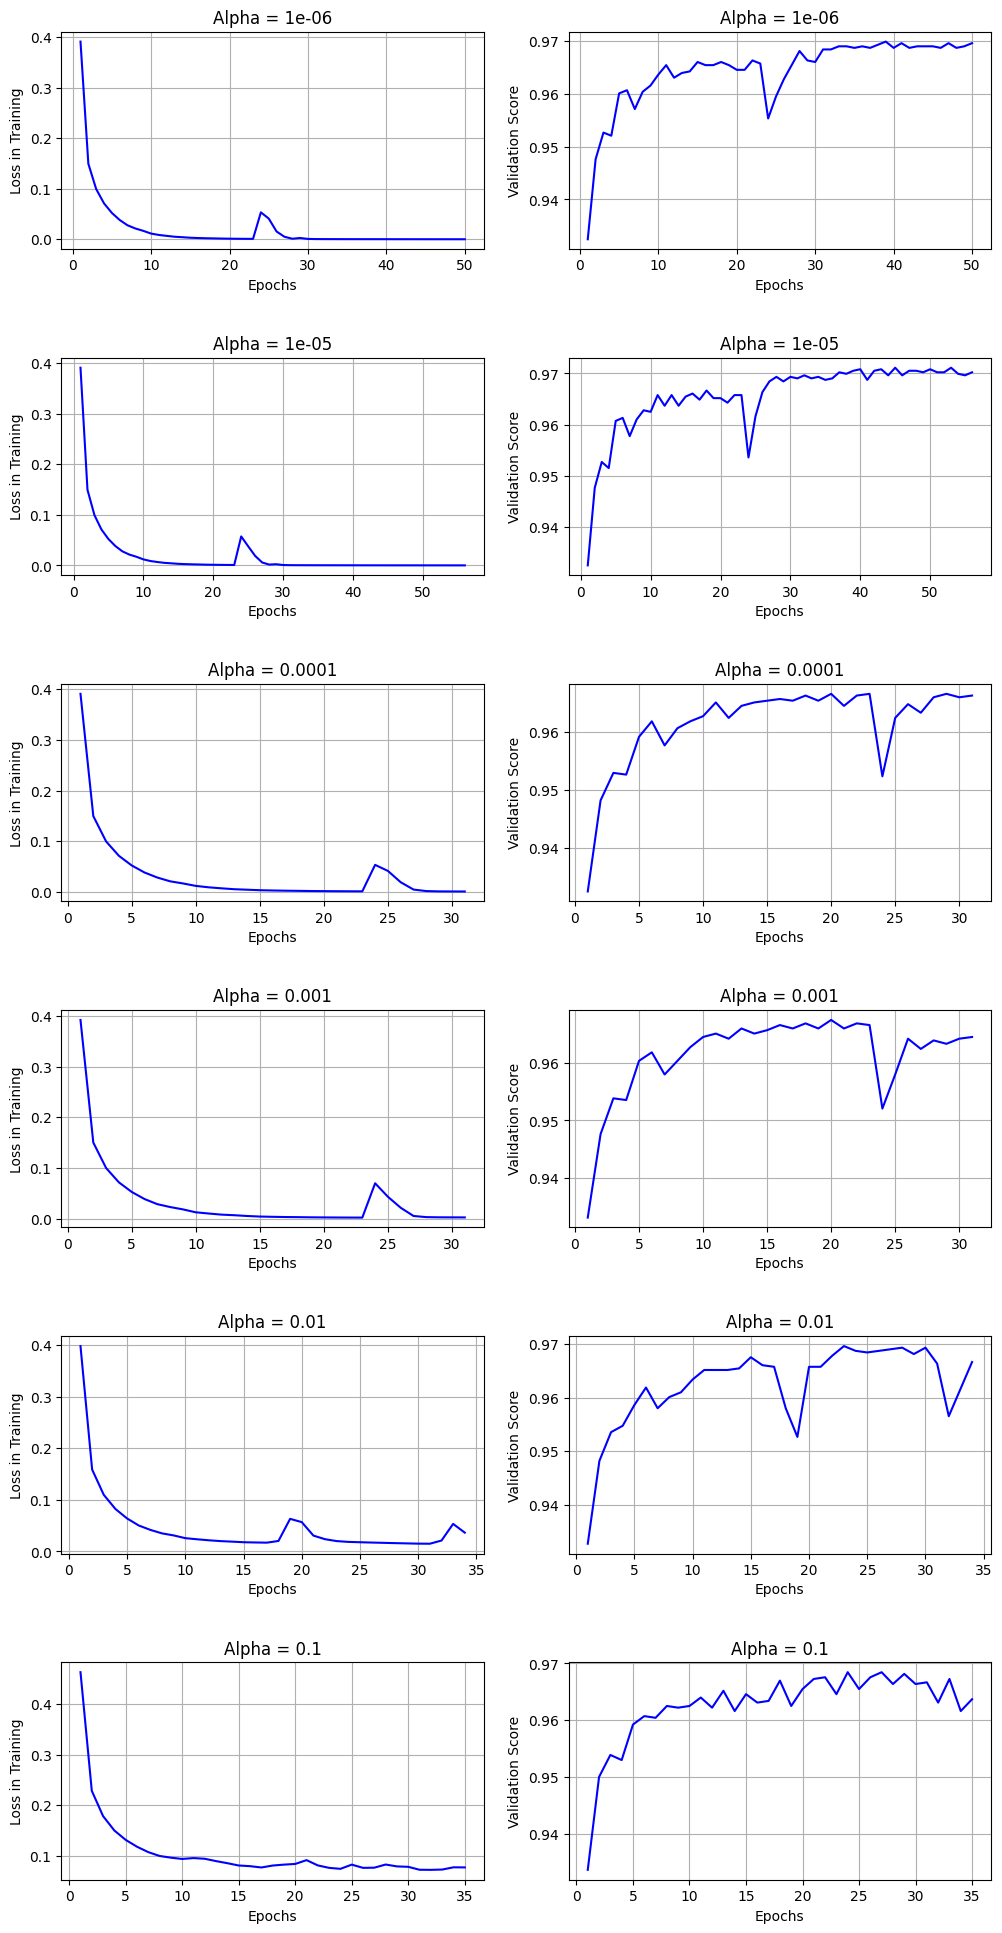

In [17]:
plot_loss_validation_curves(loss_curves, validation_score_curves, 2, "Alpha", "model__alpha")

$\textbf{Remarks about Alpha (L2 Regularization)}:$
- Stronger alphas result in a slower convergence since it restricts more the value of each gradient descent step.
- Weaker alphas need more epochs to converge, since they are free to keep making tiny imporvements in the loss function (weights are free to move more).
- The CV scores seem to be statistically equivalent for most alpha values, which indicates that for this particular dataset and NN architecture this hyper parameter isn't very important.
- Theoretically, alpha helps us reduce overfitting and imporve generalization for the following reasons: 1- when weights are too large, tiny perturbations in the features result in a considerable impact on the prediction, which hurts generalization. Alpha regularization prevents that from happening. 2- Alpha decreases the variance of the weights, which is directly linked to overfitting.

$\textbf{Studying Batch Size}$

In [18]:
## Hyper-parameter tunning
cv = CrossValidation(pipeline=clone(pipeline))
param_grid = {
    "model__batch_size": [50, 100, 200, 500, 1000, 10000, 30000],
}
cv_mlp_results, loss_curves, validation_score_curves = cv.hyper_param_tune_one_fold(X_train, y_train, X_test, y_test, param_grid, 
                                                                                    reduced=reduced, train_size=train_size, 
                                                                                    return_loss_curves=True)
cv_mlp_results

Params:  {'model__batch_size': 50}
Fit time: 92.09619688987732
Prediction time: 0.5190653800964355

Params:  {'model__batch_size': 100}
Fit time: 55.23006558418274
Prediction time: 0.3745567798614502

Params:  {'model__batch_size': 200}
Fit time: 57.733184576034546
Prediction time: 0.3958907127380371

Params:  {'model__batch_size': 500}
Fit time: 25.718937873840332
Prediction time: 0.3224172592163086

Params:  {'model__batch_size': 1000}
Fit time: 35.46237587928772
Prediction time: 0.3323197364807129

Params:  {'model__batch_size': 10000}
Fit time: 47.489718198776245
Prediction time: 0.46996021270751953

Params:  {'model__batch_size': 30000}
Fit time: 47.91333532333374
Prediction time: 0.3557417392730713

Total CV time: 364.45821142196655



,model__batch_size,fit_time,pred_time,epochs,final_loss,final_validation_score,score
2,200,57.733185,0.395891,45,0.000322,0.965774,0.968214
1,100,55.230066,0.374557,26,0.011778,0.961310,0.967857
0,50,92.096197,0.519065,28,0.012562,0.961607,0.967381
4,1000,35.462376,0.332320,52,0.003282,0.959226,0.963810
3,500,25.718938,0.322417,28,0.004620,0.960714,0.962143
5,10000,47.489718,0.469960,89,0.064259,0.948810,0.955238
6,30000,47.913335,0.355742,90,0.139573,0.938095,0.939167


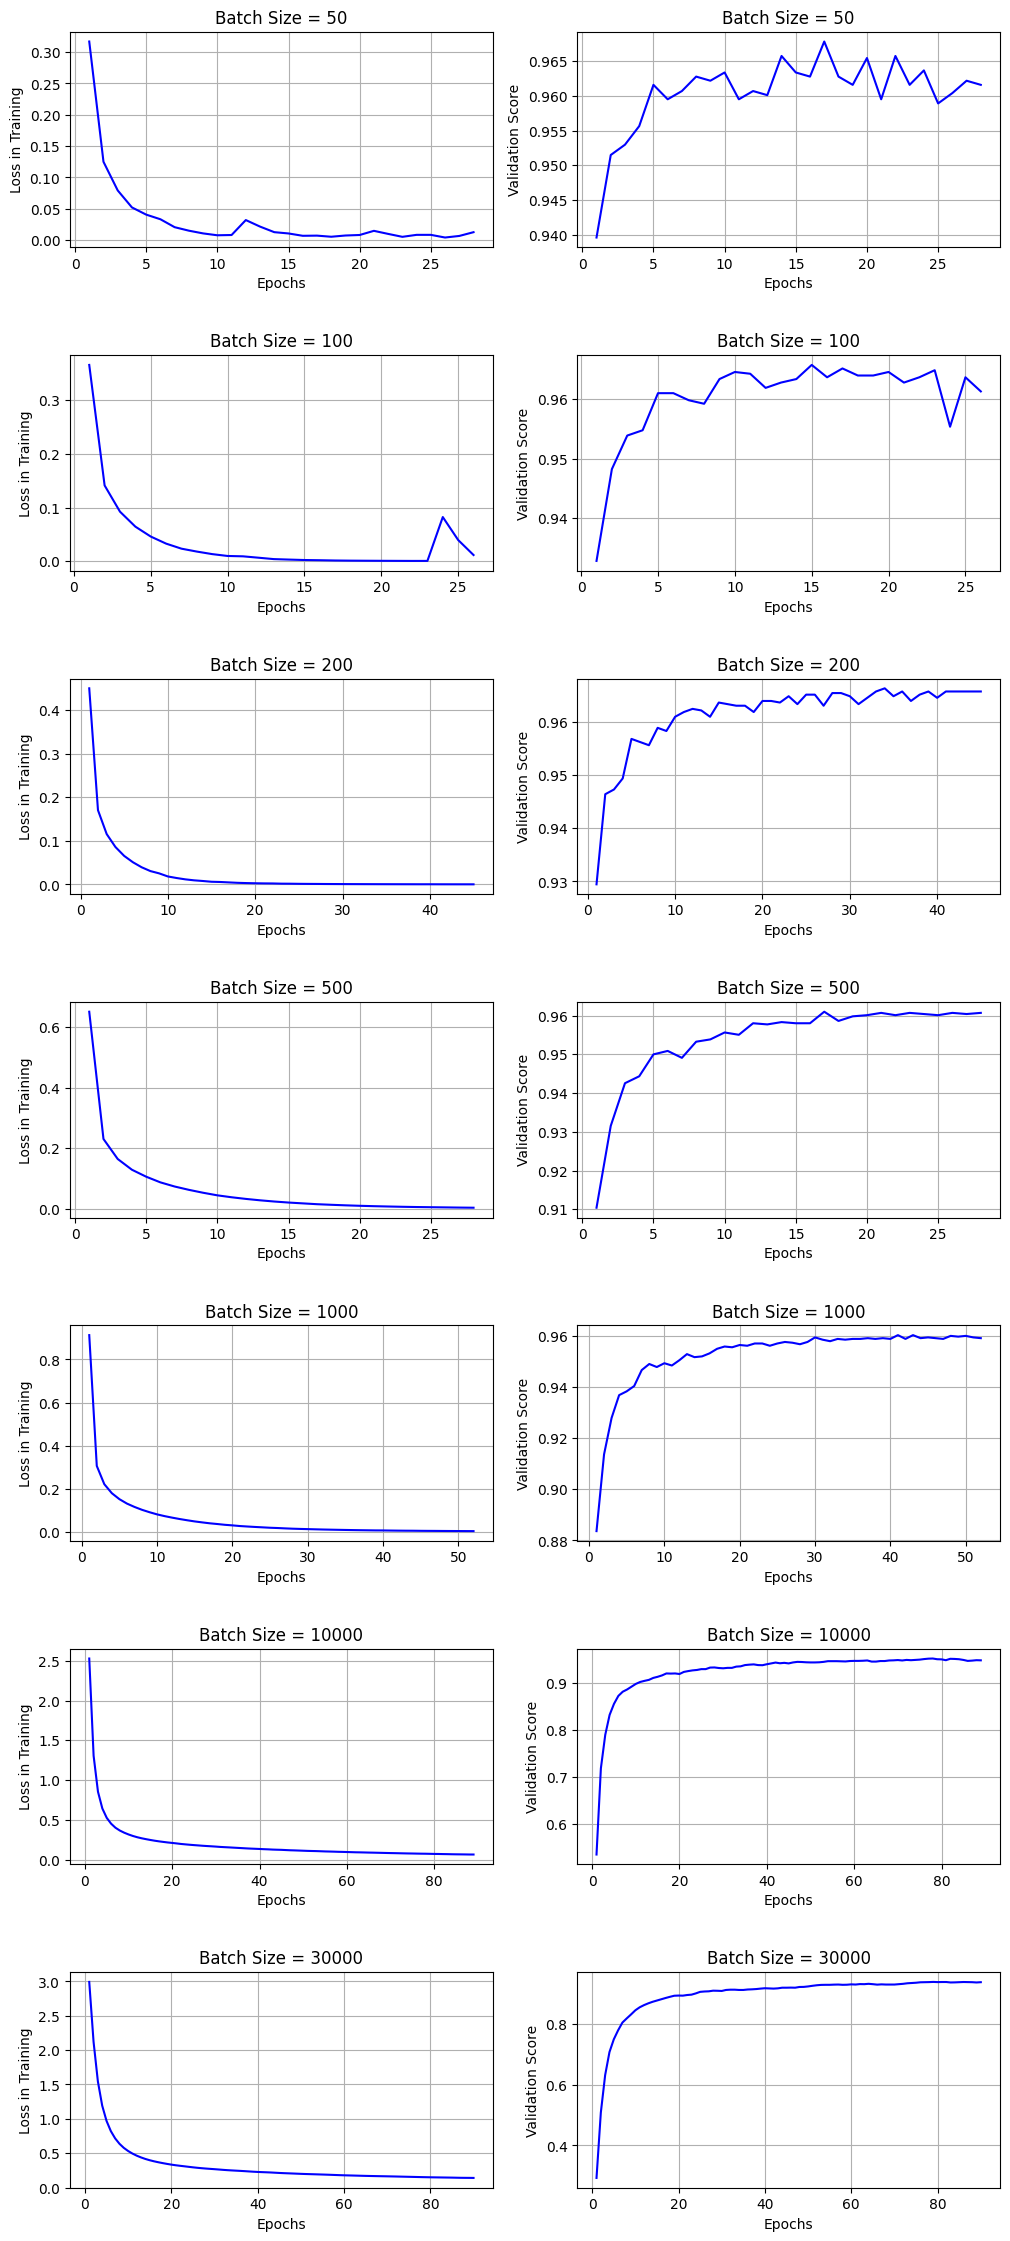

In [19]:
plot_loss_validation_curves(loss_curves, validation_score_curves, 2, "Batch Size", "model__batch_size")

$\textbf{Remarks about Batch Size}:$
- The smaller the batch size, the bigger the fit time. This happens because we are meking more updates in the weights per epoch, which causes more overhead in the optimization.
- The smaller the batch size, the smaller the number of epochs until convergence. This happens because each epoch contains more parameter updates, allowing the optimizer to make progress more frequently and often reach a good solution in fewer passes through the dataset.
- Very big batch sizes show worse performance. This may be happening because, since the gradients are more deterministic, it may be converging to sharp local minimas that don't generalize well. Noisier gradients are more capable of scaping these regions and finding flatter minimas that generalize better.